In [26]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd
import seaborn as sns

In [27]:
NUMBER_OF_FLOWS = 50

STEPS = 5

INTERVAL_LENGTH = int(NUMBER_OF_FLOWS / STEPS)

SESSIONS = np.arange(0, NUMBER_OF_FLOWS, step=INTERVAL_LENGTH)

In [28]:
def acceptance_rate(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    ar_result = []
    for slice in slices:
        values, counts = np.unique(slice, return_counts=True)
        if len(counts) == 1:
            if values[0] == 0:
                acc_rate = 0
            elif values[0] == 1:
                acc_rate = 1
        else:
            count_succ = counts[1]
            count_fail = counts[0]
            acc_rate = count_succ / (count_succ + count_fail)
        ar_result.append(acc_rate)

    return ar_result

In [29]:
def resource_utilization(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    resource_result = []
    for slice in slices:
        if len(slice) == 0:
            continue
        average_consumption = np.mean(slice)
        resource_result.append(average_consumption)

    return resource_result

In [40]:
def plot_resource_utilization(resource_series: pd.Series, title, y_lim):

    index_resource = pd.MultiIndex.from_tuples(
        dict(resource_series).keys(), names=["sfc", "algorithm", "speed", "exec"]
    )

    resource_df = pd.DataFrame.from_dict(dict(resource_series), orient="index")

    resource_df = resource_df.set_index(index_resource)

    grouped_resource = resource_df.groupby(level=("sfc", "algorithm", "speed"))

    mean_df = grouped_resource.mean()
    std_df = grouped_resource.std()

    mean_df = mean_df.stack().to_frame("mean")
    mean_df["std"] = std_df.stack().to_frame("std")
    alg_names = ["MSF", "MusFiCO"]

    mean_df = mean_df.reset_index()
    fig, ax = plt.subplots(ncols=1, figsize=(10, 5))
    for idx, (key, series) in enumerate(mean_df.groupby(["sfc", "algorithm"])):
        ax.set_title(f"{alg_names[idx]}, SFC = {key[0]}")  # Remove [idx]
        ax.set_xlabel("Sessions")
        ax.set_ylabel(title)
        ax.set_ylim(y_lim)
        ax.set_xticks(ticks=list(range(0, 11)), labels=[str(x) for x in list(range(5, 56, 5))])
        # ax[idx].set_xticks(labels=SESSIONS)
        sns.lineplot(
            x="level_3",
            y="mean",
            hue="speed",
            data=series,
            ax=ax,
            err_style="bars",
            style="speed",
            markers=True,
        )

    fig.tight_layout()
    fig.show()

In [31]:
results_flows_directories = glob.glob("../results_flows_*/*")

In [32]:
results_flows_directories

['..\\results_flows_50\\dp_35_sfc_on_con_1']

In [33]:

df = pd.DataFrame()

for alg_dir in results_flows_directories:
    files = os.listdir(alg_dir)
    simu_exec_name = alg_dir.split("/")[-1].split("_")
    alg_name = simu_exec_name[0]
    sfc = simu_exec_name[3]
    vel = simu_exec_name[-1]
    for idx, file in enumerate(files):
        data_path = os.path.join(alg_dir, file)

        try:
            simulation_df = pd.read_csv(data_path)
        except:
            continue

        simulation_df["algorithm"] = alg_name
        simulation_df["sfc"] = sfc
        simulation_df["speed"] = vel
        simulation_df["exec"] = idx

        df = pd.concat([df, simulation_df], axis=0)

In [34]:
grouped_df = df.groupby(["sfc", "algorithm", "speed", "exec"])

In [35]:
ar_series = grouped_df["success"].apply(acceptance_rate)

resource_df = pd.DataFrame.from_dict(dict(ar_series), orient="columns").T

resource_df.index.names = ["sfc", "algorithm", "speed", "exec"]

In [36]:
ar_mean_df = resource_df.groupby(level=["sfc", "algorithm", "speed"]).mean()

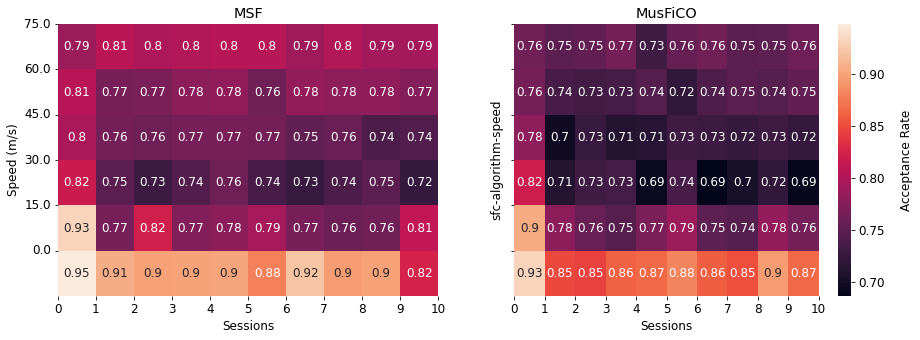

In [41]:
n_alg = len(np.unique(ar_mean_df.index.get_level_values("algorithm")))

fig, ax = plt.subplots(ncols=n_alg, figsize=(15, 5))
plt.rcParams["font.size"] = 12
vmin, vmax = 1000, 0
cmap = sns.color_palette("rocket", as_cmap=True)

for idx, (key, group) in enumerate(ar_mean_df.groupby(level=["sfc", "algorithm"])):
    vmin = group.min().min() if group.min().min() < vmin else vmin
    vmax = group.max().max() if group.max().max() > vmax else vmax
alg_names = ["MSF", "MusFiCO"]
for idx, (key, group) in enumerate(ar_mean_df.groupby(level=["sfc", "algorithm"])):
    group = group.iloc[::-1]
    velocity = group.index.get_level_values(-1).values
    sessions = group.columns.values
    sessions = list(range(0, len(sessions) + 1))
    yticks = np.arange(len(velocity))

    if idx == 0:
        pk = sns.heatmap(
            group, ax=ax[idx], vmin=vmin, vmax=vmax, cmap=cmap, annot=True, cbar=False
        )
        ax[idx].set_yticks(ticks=yticks, labels=velocity)
        ax[idx].set_ylabel("Speed (m/s)")
    else:
        pk = sns.heatmap(group, ax=ax[idx], vmin=vmin, vmax=vmax, cmap=cmap, annot=True)
        ax[idx].set_yticks(ticks=yticks, loc=None)
        # ax[idx].tick_params(left=False, bottom=False) ## other options are right and top

    # cbar = pk.collections[0].colorbar
    # cbar.set_label('Acceptance Rate', rotation=90, labelpad=15)

    ax[idx].set_xticks(ticks=sessions, labels=sessions)

    ax[idx].set_xlabel("Sessions")
    # ax[idx].set_title(f'{alg_names[idx]}, SFC = {key[0]}')
    ax[idx].set_title(f"{alg_names[idx]}")
cbar = pk.collections[0].colorbar
cbar.set_label("Acceptance Rate", rotation=90, labelpad=15)

In [37]:
acceptance_series = grouped_df["success"].apply(resource_utilization)
bd_series = grouped_df["cache_utilization"].apply(resource_utilization)
cache_series = grouped_df["bandwidth_utilization"].apply(resource_utilization)
cpu_series = grouped_df["cpu_utilization"].apply(resource_utilization)
decision_time_series = grouped_df["duration"].apply(resource_utilization)

In [38]:
latency_df = df[df["latency"] != "None"]

latency_df["latency"] = latency_df["latency"].astype(float)

latency_series = latency_df.groupby(["sfc", "algorithm", "speed", "exec"])["latency"].apply(
    resource_utilization
)

C:\Users\Demop\AppData\Local\Temp\ipykernel_15472\3283871223.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latency_df['latency'] = latency_df['latency'].astype(float)


sfc  algorithm   speed  exec
35   ..\results  1      0       [0.8831168831168831, 0.8181818181818182, 0.779...
                        1       [0.8928571428571429, 0.8333333333333334, 0.75,...
                        2       [0.8846153846153846, 0.8461538461538461, 0.756...
                        3       [0.8783783783783784, 0.8243243243243243, 0.810...
                        4       [0.8860759493670886, 0.810126582278481, 0.7974...
                        5       [0.8846153846153846, 0.8205128205128205, 0.782...
                        6       [0.8860759493670886, 0.810126582278481, 0.7848...
                        7       [0.881578947368421, 0.8266666666666667, 0.7866...
                        8       [0.8831168831168831, 0.8181818181818182, 0.779...
                        9       [0.8846153846153846, 0.8181818181818182, 0.753...
                        10      [0.8831168831168831, 0.8181818181818182, 0.766...
                        11      [0.8860759493670886, 0.77215189873417

c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
C:\Users\Demop\AppData\Local\Temp\ipykernel_15472\316270065.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


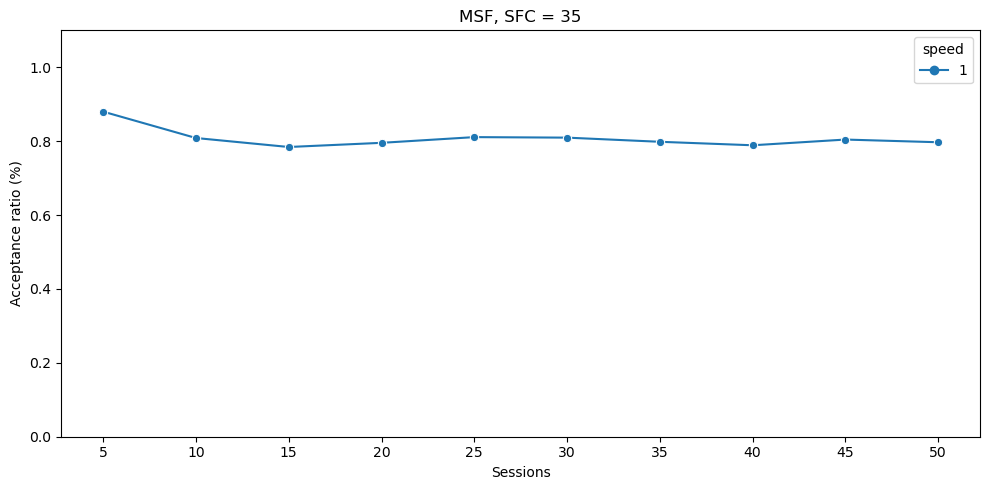

In [41]:
print(acceptance_series)
acceptance_array = plot_resource_utilization(
    acceptance_series, title="Acceptance ratio (%)", y_lim=(0, 1.1)
)

c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
C:\Users\Demop\AppData\Local\Temp\ipykernel_15472\316270065.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


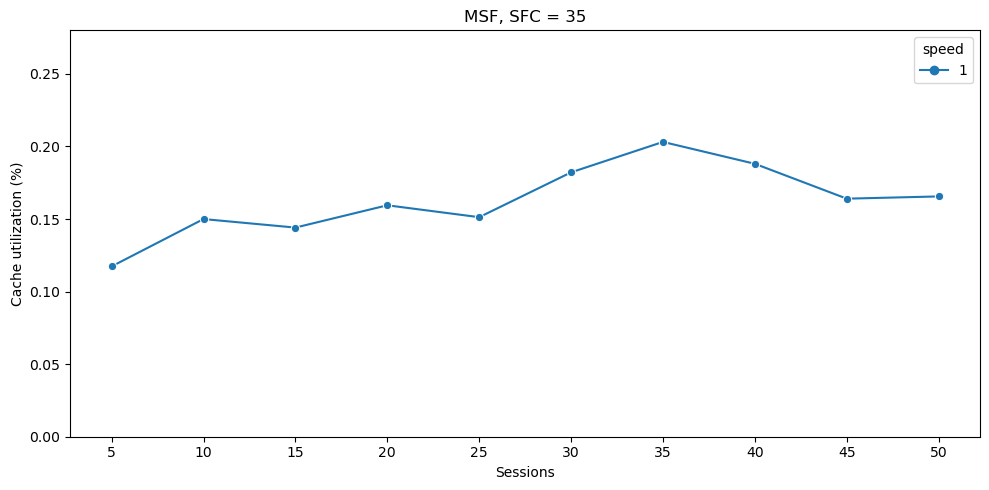

In [44]:
cache_array = plot_resource_utilization(
    cache_series, title="Cache utilization (%)", y_lim=(0, 0.280)
)

c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
C:\Users\Demop\AppData\Local\Temp\ipykernel_15472\316270065.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


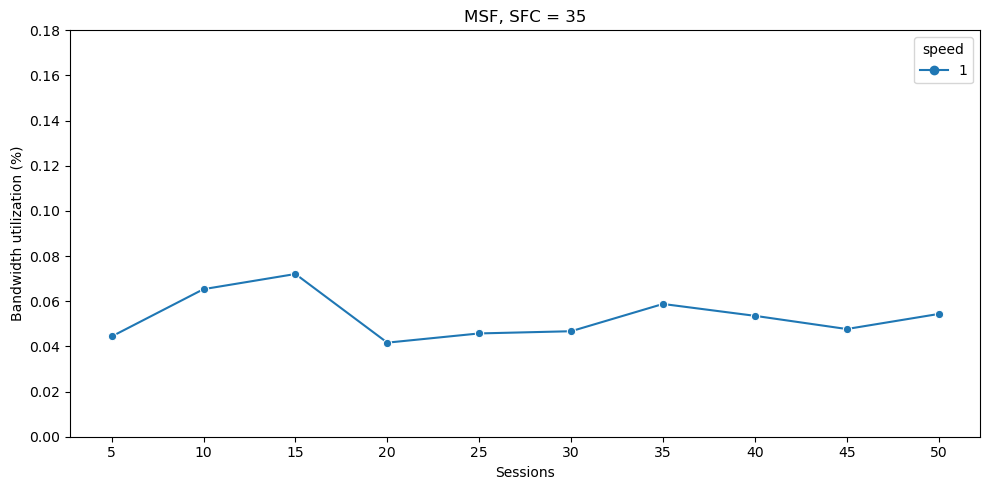

In [45]:
bandwidth_array = plot_resource_utilization(
    bd_series, title="Bandwidth utilization (%)", y_lim=(0, 0.18)
)

c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
C:\Users\Demop\AppData\Local\Temp\ipykernel_15472\316270065.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


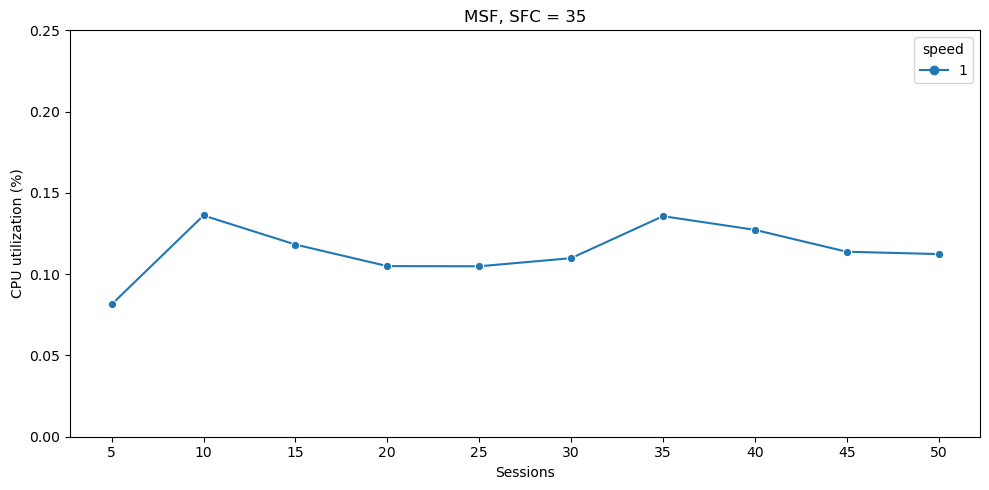

In [48]:
cpu_array = plot_resource_utilization(cpu_series, "CPU utilization (%)", y_lim=(0, 0.25))

c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
C:\Users\Demop\AppData\Local\Temp\ipykernel_15472\316270065.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


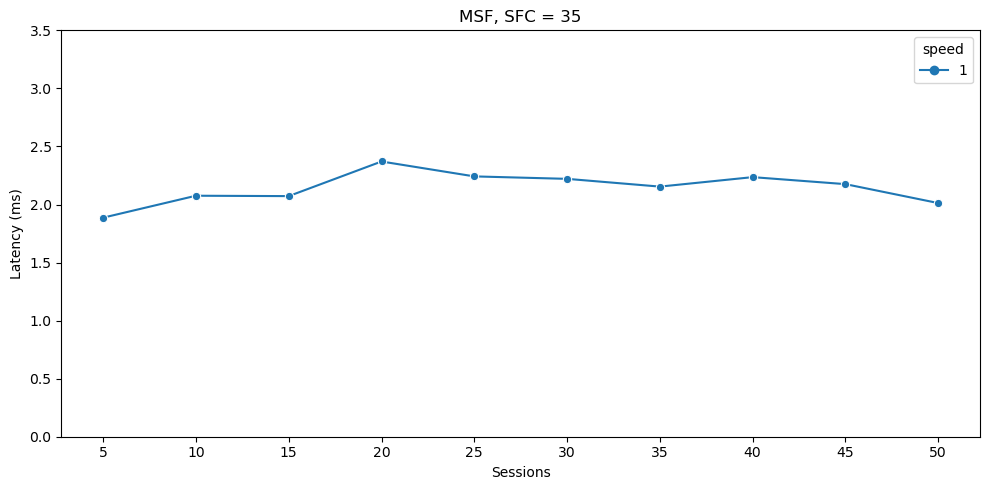

In [49]:
latency_array = plot_resource_utilization(latency_series, title="Latency (ms)", y_lim=(0, 3.5))

c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\Demop\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
C:\Users\Demop\AppData\Local\Temp\ipykernel_15472\316270065.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


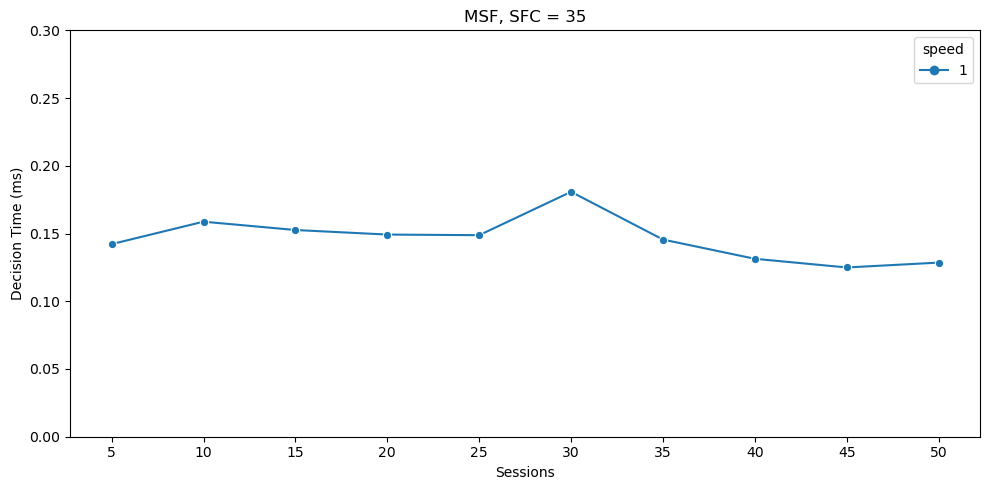

In [53]:
decision_time_array = plot_resource_utilization(
    decision_time_series, title="Decision Time (ms)", y_lim=(0, 0.3)
)

In [112]:
def format_acceptance_boxplot(df):
    df = pd.DataFrame(df)
    # print(df)
    speeds = [x for x in np.unique(df.index.get_level_values("speed"))]
    algs = [x for x in np.unique(df.index.get_level_values("algorithm"))]
    dic = {}
    for alg in algs:
        d_velocitys = []
        for sp in speeds:
            ar = df.query("('{0}' == speed) & (algorithm == '{1}')".format(sp, alg))
            ar = ar.values.tolist()
            partitions = np.array_split(np.array(ar), 10)
            stacked_partitions = np.vstack(partitions)
            print(stacked_partitions)
            result = (np.mean(stacked_partitions, axis=0) / 10).ravel()
            print(result)
            d_velocitys.append(result)
        dic[str(alg)] = d_velocitys
    # print(pd.DataFrame(dic,index=speeds))
    return pd.DataFrame(dic, index=speeds)

In [ ]:
def format_resource_boxplot(df):
    df = pd.DataFrame(df)
    # print(df)
    speeds = [x for x in np.unique(df.index.get_level_values("speed"))]
    algs = [x for x in np.unique(df.index.get_level_values("algorithm"))]
    dic = {}
    for alg in algs:
        d_velocitys = []
        for sp in speeds:
            ar = df.query("('{0}' == speed) & (algorithm == '{1}')".format(sp, alg))
            ar = ar.values.tolist()
            partitions = np.array_split(np.array(ar), len(ar))
            stacked_partitions = np.vstack(partitions)
            print(stacked_partitions)
            result = (np.sum(stacked_partitions, axis=0) / len(stacked_partitions)).ravel()
            print(result)
            d_velocitys.append(result)
        dic[str(alg)] = d_velocitys
    # print(pd.DataFrame(dic,index=speeds))
    return pd.DataFrame(dic, index=speeds)

In [114]:
def plot_resource_boxplot(data_boxplot, ylabel, unit, fontsize=18):
    plt.figure(figsize=(12, 6))
    width = 3
    fontsize = fontsize

    data_a = data_boxplot["dp"].tolist()
    data_b = data_boxplot["musfico"].tolist()
    # print(data_a)
    positions = [0, 15, 30, 45, 60, 75]

    boxes1 = plt.boxplot(
        data_a,
        notch=0,
        patch_artist=True,
        positions=positions,
        sym="",
        widths=width,
        zorder=3,
        flierprops={"markersize": 8},
    )
    boxes2 = plt.boxplot(
        data_b,
        notch=0,
        patch_artist=True,
        positions=[p + 3 for p in positions],
        sym="",
        widths=width,
        zorder=3,
        flierprops={"markersize": 8},
    )

    plt.grid(lw=2, zorder=0)
    plt.xticks(positions, ["0", "15", "30", "45", "60", "75"], fontsize=fontsize)
    plt.xlabel("Speed(km/h)", fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.ylabel(ylabel + " (" + unit + ")", fontsize=fontsize)

    colors = ["#0000FF", "#FF0000"]

    for patch in boxes1["boxes"]:
        patch.set_facecolor(colors[0])
    for patch in boxes2["boxes"]:
        patch.set_facecolor(colors[1])

    plt.legend(
        [boxes1["boxes"][0], boxes2["boxes"][0]], ["MSF", "MUSFICO"], loc="best", fontsize=fontsize
    )
    plt.tight_layout()
    plt.savefig(ylabel + ".png")
    plt.show()

[[[1.    0.95  0.95  0.675 0.975 0.7   0.975 1.    0.925 0.475]]

 [[0.95  0.8   0.8   0.85  1.    0.8   0.7   0.85  1.    0.65 ]]

 [[0.825 1.    0.825 0.775 0.9   1.    1.    1.    0.8   0.95 ]]

 [[0.85  0.8   0.95  0.65  1.    0.975 0.95  0.85  0.825 0.825]]

 [[1.    0.8   0.9   0.85  0.7   0.8   0.975 0.975 0.925 0.85 ]]

 [[1.    0.8   1.    0.975 0.7   0.95  1.    0.9   1.    0.975]]

 [[1.    0.825 0.8   0.95  0.925 0.75  0.95  0.95  1.    0.95 ]]

 [[0.85  0.8   1.    0.8   1.    0.925 0.825 0.975 0.825 1.   ]]

 [[1.    0.9   1.    0.9   1.    0.9   0.9   0.925 0.625 0.825]]

 [[1.    0.925 1.    0.8   0.8   0.825 1.    0.8   0.975 0.9  ]]

 [[1.    0.95  0.825 1.    1.    0.9   0.975 0.8   0.8   0.7  ]]

 [[1.    0.825 0.675 1.    0.8   0.75  0.8   0.65  0.95  0.9  ]]

 [[1.    1.    0.9   1.    1.    0.85  0.9   1.    0.8   0.6  ]]

 [[1.    0.625 0.825 0.95  0.875 0.975 0.925 1.    0.925 0.875]]

 [[1.    1.    0.775 1.    0.8   0.825 1.    1.    0.95  0.85 ]]

 [[1.    1

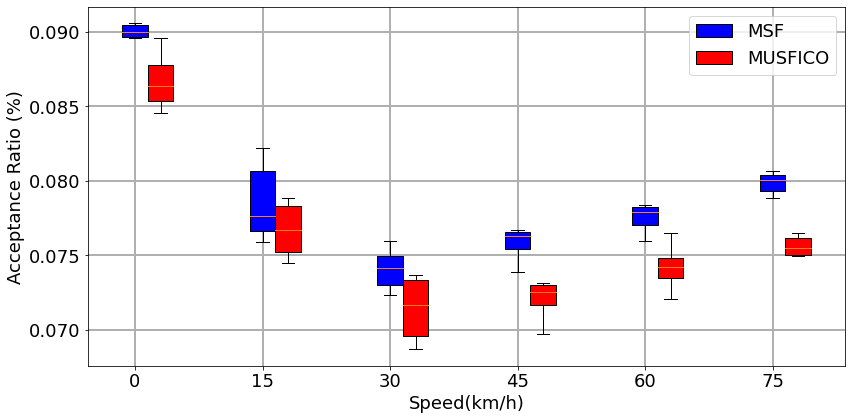

In [115]:
# print(acceptance_series)
plot_resource_boxplot(
    format_acceptance_boxplot(acceptance_series), ylabel="Acceptance Ratio", unit="%"
)

sfc  algorithm  speed  exec
on   dp         0.0    0       [0.17987179487179483, 0.5006923076923077, 0.56...
                       1       [0.17544871794871794, 0.4858012820512821, 0.48...
                       2       [0.15067948717948715, 0.44849999999999995, 0.5...
                       3       [0.16630769230769227, 0.43582051282051293, 0.4...
                       4       [0.17987179487179483, 0.4835897435897435, 0.41...
                                                     ...                        
     musfico    75.0   25      [0.17920595533498757, 0.2828866832092637, 0.28...
                       26      [0.14047692307692308, 0.27706153846153836, 0.2...
                       27      [0.19687028657616884, 0.30180995475113115, 0.2...
                       28      [0.16635440467123627, 0.23706524498603695, 0.2...
                       29      [0.16963800904977364, 0.23503016591251893, 0.2...
Name: cpu_utilization, Length: 350, dtype: object
[[[0.17987179 0.50069231 0.5665

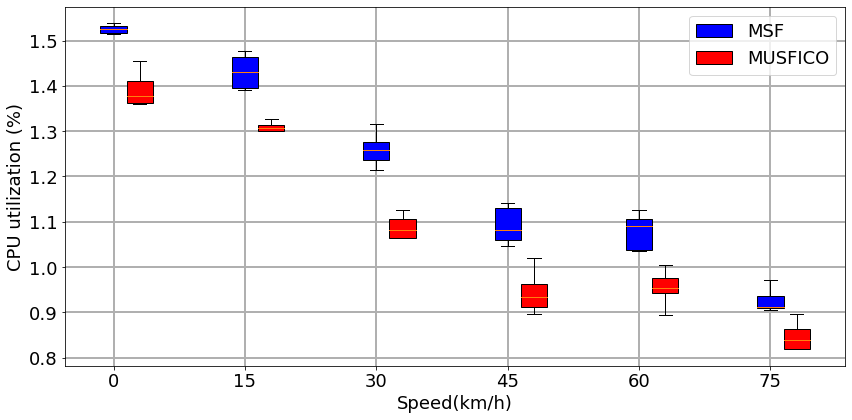

In [102]:
print(cpu_series)
plot_resource_boxplot(format_resource_boxplot(cpu_series), ylabel="CPU utilization", unit="%")

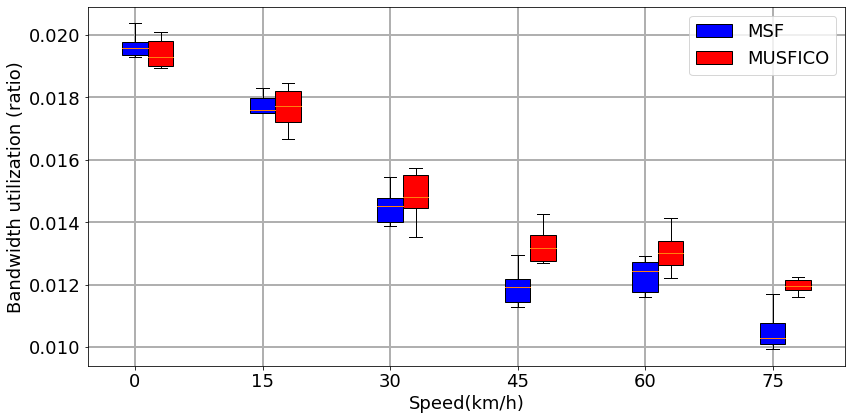

In [90]:
plot_resource_boxplot(
    format_resource_boxplot(bd_series), ylabel="Bandwidth utilization", unit="ratio"
)

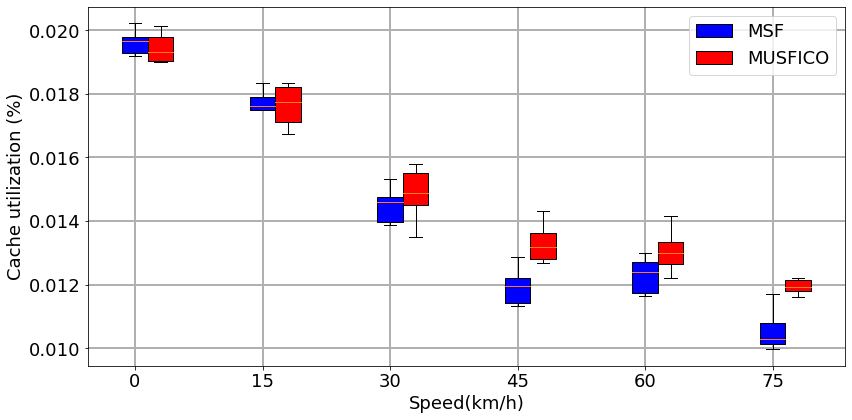

In [91]:
plot_resource_boxplot(format_resource_boxplot(cache_series), ylabel="Cache utilization", unit="%")

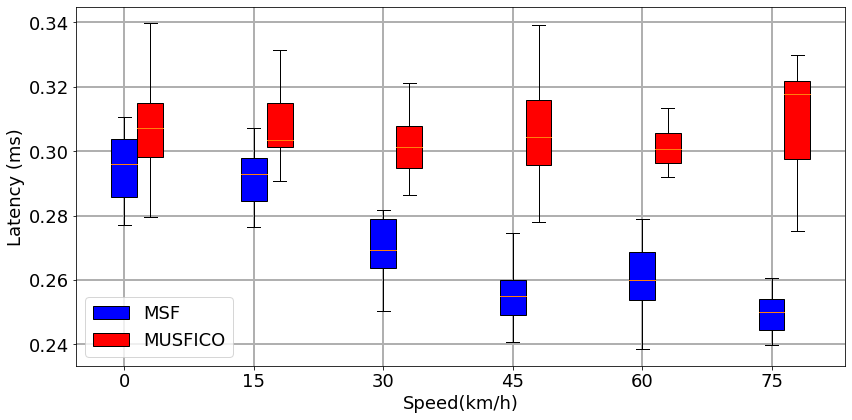

In [92]:
plot_resource_boxplot(format_resource_boxplot(latency_series), ylabel="Latency", unit="ms")